In [1]:
import sys
import torch
import pandas as pd

from tqdm.auto import tqdm
from pathlib import Path
from torch.utils.data import DataLoader

/home/ghandill/miniconda3/envs/fresh_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.append("../../modules/PPB-Affinity")
sys.path.append("../../modules/PPB-Affinity-HF")

In [4]:
from inference import InferDataset_Struc
from BaselineModel.utils.data import PaddingCollate_struc
from BaselineModel.utils.train import CrossValidation, recursive_to
from BaselineModel.models.dg_model import DG_Network

In [5]:
args = {
    "checkpoint_path": "/home/ghandill/masterthesis_lilit_ghandilyan/modules/PPB-Affinity-HF/checkpoints/checkpoint.pt",
    "device": torch.device("cuda" if (torch.cuda.is_available()) else "cpu"),
    "affinity_file_path": "/home/ghandill/masterthesis_lilit_ghandilyan/data/affinity_data.csv"
}

In [6]:
project_root = Path.cwd().parent.parent  # adjust as needed
data_path_base = project_root / "data"

affinity_path = data_path_base / "processed_data.csv"
affinity_df = pd.read_csv(affinity_path, index_col=0)

In [9]:
ckpt = torch.load(args["checkpoint_path"], map_location=args["device"], weights_only=False)
config = ckpt['config']
print(config)

cv_mgr = CrossValidation(
    model_factory=DG_Network,
    config=config,
    num_cvfolds=config['train']['num_cvfolds'],
)
cv_mgr.load_state_dict(ckpt['model'])
cv_mgr.to(args["device"])

{'model': {'encoder': {'node_feat_dim': 128, 'pair_feat_dim': 64, 'num_layers': 3}, 'max_num_atoms': 15, 'num_classes': 1}, 'data': {'strict': True, 'finetune': False, 'reset': False, 'split_seed': 2024, 'csv_path': './benchmark.csv', 'cache_dir': './benchmark_cache', 'logdir': './log_dir', 'transform': {'train': [{'type': 'select_atom', 'resolution': 'full'}, {'type': 'add_atom_noise'}, {'type': 'add_chi_angle_noise'}, {'type': 'selected_region_fixed_size_patch', 'select_attr': 'itf_flag', 'patch_size': 128}], 'val': [{'type': 'select_atom', 'resolution': 'full'}, {'type': 'selected_region_fixed_size_patch', 'select_attr': 'itf_flag', 'patch_size': 128}]}, 'lable_type': ['dG'], 'blocklist': ['4R8I', '1FYT']}, 'train': {'loss_weights': {'regression': 1.0, 'regular': 1.0}, 'num_cvfolds': 5, 'max_iters': 100000, 'val_freq': 1000, 'batch_size': 16, 'seed': 2024, 'max_grad_norm': 100.0, 'optimizer': {'type': 'adamw', 'lr': 0.0005, 'weight_decay': 0, 'beta1': 0.9, 'beta2': 0.999}, 'schedule

In [ ]:
affinity_df_skempi = affinity_df[affinity_df["source"] == "SKEMPI v2.0"]
affinity_df_skempi_mut = affinity_df_skempi[~affinity_df_skempi["mutstr"].isna()]

In [ ]:
import pandas as pd
import numpy as np

# 1. Sample 500 random rows from the dataframe
affinity_df_sample_mutstr = affinity_df_skempi_mut.sample(n=2000, random_state=42)

# 2. Make a copy of the sampled dataframe
affinity_df_copy = affinity_df_sample_mutstr.copy()

# 3. Set all values in 'mutstr' column to NaN
affinity_df_copy['mutstr'] = np.nan

# 4. Drop duplicates based on 'pdb'
affinity_df_no_mutstr_unique = affinity_df_copy.drop_duplicates(subset='pdb', keep='first')

# Optional: Check result
print(affinity_df_no_mutstr_unique.shape)
affinity_df_no_mutstr_unique.head()


(242, 11)


,source,pdb,mutstr,ligand,receptor,KD,resolution,Subgroup,dG,split,pdb_path
3436,SKEMPI v2.0,3sgb,NaN,E,I,8.330000e-11,1.8,NaN,-13.749965,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
5117,SKEMPI v2.0,3s9d,NaN,A,B,3.400000e-08,2.0,NaN,-10.188341,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
3875,SKEMPI v2.0,1mi5,NaN,"A, B, C","D, E",1.000000e-04,2.5,TCR-pMHC,-5.456684,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
2655,SKEMPI v2.0,1cho,NaN,"E, F, G",I,1.390000e-09,1.8,NaN,-12.082443,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
2050,SKEMPI v2.0,1gc1,NaN,G,C,2.890000e-08,2.5,NaN,-10.284625,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...


In [12]:
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from Bio.PDB.PDBParser import PDBParser
from Bio.PDB.Polypeptide import one_to_index
from tqdm.auto import tqdm

from BaselineModel.utils.data import PaddingCollate_struc
from BaselineModel.utils.train import *
from BaselineModel.utils.transforms import Compose, SelectAtom, SelectedRegionFixedSizePatch
from BaselineModel.utils.protein.parsers import parse_biopython_structure
from BaselineModel.utils.transforms import _index_select_data
from inference import _parse_mut

In [ ]:

class InferDataset_Struc(Dataset):
    def __init__(self, df=None, generated_sequences=None):
        super().__init__()
        self.entries = self.load_struc_entries(df)
        self.structures = self.load_structures()
        self.transform = Compose([
            SelectAtom('full'),
            SelectedRegionFixedSizePatch('itf_flag', 128)
        ])

    def load_struc_entries(self, df):
        entries = []

        for i, r in df.iterrows():
            pdb_name = r['pdb']
            ligand_chains = r['ligand']
            receptor_chains = r['receptor']
            dG = r['dG']
            pdb_path = r['pdb_path']

            entry = {
                'id': i,
                'complex': pdb_name + str(r['mutstr']),
                'mutstr': str(r['mutstr']),
                'num_muts': 0 if isinstance(r['mutstr'], float) else 1,
                'pdbcode': pdb_name,
                'group_ligand': ligand_chains,
                'group_receptor': receptor_chains,
                'mutations': (
                    [None]
                    if isinstance(r['mutstr'], float)
                    else list(map(_parse_mut, r['mutstr'].replace(' ', '').split(',')))
                ),
                'dG': np.float32(dG),
                'pdb_path': pdb_path,
            }
            entries.append(entry)

        return entries
    
    def load_structures(self):
        structures = {}
        pdbcodes = [e['pdbcode'] for e in self.entries]
        pdb_paths = [e['pdb_path'] for e in self.entries]
        for pdbcode, pdb_path in tqdm(zip(pdbcodes, pdb_paths), desc='Structures'):
            if pdbcode in structures:
                continue
            parser = PDBParser(QUIET=True)
            model = parser.get_structure(None, pdb_path)[0]
            data, seq_map = parse_biopython_structure(model)
            print(seq_map)
            structures[pdbcode] = (data, seq_map)
        return structures

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, index):
        entry = self.entries[index]
        data, seq_map = copy.deepcopy(self.structures[entry['pdbcode']])
        keys = {'id', 'complex', 'mutstr', 'num_muts', 'pdbcode', 'dG'}
        for k in keys:
            try:
                data[k] = entry[k]
            except:
                pass

        data['ID'] = f"{data['pdbcode']}_{data['mutstr']}_{entry['group_receptor']}_{entry['group_ligand']}"

        group_id = []
        for ch in data['chain_id']:
            if ch in entry['group_ligand']:  # 1 is ligand
                group_id.append(1)
            elif ch in entry['group_receptor']:  # 2 is receptor
                group_id.append(2)
            else:
                group_id.append(0)
        data['group_id'] = torch.LongTensor(group_id)

        if entry['num_muts'] > 0:
            aa_mut = data['aa'].clone()
            for mut in entry['mutations']:
                ch_rs_ic = (mut['chain'], mut['resseq'], mut['icode'])
                if ch_rs_ic not in seq_map: continue
                aa_mut[seq_map[ch_rs_ic]] = one_to_index(mut['mt'])
            data['mut_flag'] = (data['aa'] != aa_mut)
            data['aa'] = aa_mut
        else:
            data['mut_flag'] = torch.full_like(data['aa'], False, dtype=torch.bool)

        idx_keep = torch.where(data['group_id'] != 0)[0]
        data = _index_select_data(data, idx_keep)

        idx_ligand = torch.where(data['group_id'] == 1)[0]
        idx_receptor = torch.where(data['group_id'] == 2)[0]
        dist_pair = torch.cdist(data['pos_heavyatom'][idx_ligand, 1, :],
                                data['pos_heavyatom'][idx_receptor, 1, :])  # 1 is CA atom

        idx_ligand_itf, idx_receptor_itf = torch.where(dist_pair < 10.0)
        idx_ligand_itf = idx_ligand[torch.unique(idx_ligand_itf)]
        idx_receptor_itf = idx_receptor[torch.unique(idx_receptor_itf)]
        idx_itf = torch.cat([idx_ligand_itf, idx_receptor_itf])
        data['itf_flag'] = torch.full_like(data['aa'], False, dtype=torch.bool)
        data['itf_flag'][idx_itf] = True
        if data['itf_flag'].sum()==0:
            raise ValueError("No binding site found")

        return self.transform(data)


In [31]:
pdb_path = affinity_df["pdb_path"].iloc[100]

In [32]:
parser = PDBParser(QUIET=True)
model = parser.get_structure(None, pdb_path)[0]
data, seq_map = parse_biopython_structure(model)

In [ ]:
protein_ids = [sample["protein_id"] for sample in sequence_samples]
unique_protein_ids = list(set(protein_ids))
pdb_codes = [protein_id[:4].lower() for protein_id in unique_protein_ids]

filtered_affinity_df = affinity_df[affinity_df['pdb'].isin(pdb_codes)]

filtered_affinity_df['mutstr']
print(filtered_affinity_df)


             source   pdb       mutstr ligand receptor            KD  \
7       SKEMPI v2.0  1b2u          NaN      A        D  1.000000e-07   
519     SKEMPI v2.0  1b2u        AA27K      A        D  2.000000e-11   
520     SKEMPI v2.0  1b2u        AD36D      A        D  8.800000e-11   
521     SKEMPI v2.0  1b2u  AA27K,AD36D      A        D  1.000000e-14   
7943  PDBbind v2020  1b2u          NaN      D        A  1.000000e-07   
7944  PDBbind v2020  1b2u          NaN      E        B  1.000000e-07   
7945  PDBbind v2020  1b2u          NaN      F        C  1.000000e-07   

      resolution Subgroup         dG split  \
7            2.1      NaN  -9.549198   val   
519          2.1      NaN -14.595226   val   
520          2.1      NaN -13.717446   val   
521          2.1      NaN -19.098395   val   
7943         2.1      NaN  -9.549198   val   
7944         2.1      NaN  -9.549198   val   
7945         2.1      NaN  -9.549198   val   

                                               pdb_pat

In [44]:
affinity_df

,source,pdb,mutstr,ligand,receptor,KD,resolution,Subgroup,dG,split,pdb_path
0,SKEMPI v2.0,1a22,NaN,A,B,9.000000e-10,2.60,NaN,-12.339961,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
1,SKEMPI v2.0,1a4y,NaN,A,B,5.000000e-16,2.00,NaN,-20.873223,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
2,SKEMPI v2.0,1acb,NaN,E,I,1.490000e-12,2.00,NaN,-16.133798,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
3,SKEMPI v2.0,1ahw,NaN,"A, B",C,3.400000e-09,3.00,NaN,-11.552512,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
4,SKEMPI v2.0,1ak4,NaN,A,D,1.200000e-05,2.36,NaN,-6.712839,val,/home/ghandill/masterthesis_lilit_ghandilyan/d...
...,...,...,...,...,...,...,...,...,...,...,...
12050,ATLAS,4l3e,EA166A,"A, C","D, E",3.220000e-05,2.56,TCR-pMHC,-6.128053,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
12051,ATLAS,4l3e,"QA155A,YD50A","A, C","D, E",7.710000e-05,2.56,TCR-pMHC,-5.610762,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
12052,ATLAS,4l3e,"EA166A,ND52A","A, C","D, E",2.610000e-05,2.56,TCR-pMHC,-6.252487,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...
12053,ATLAS,4l3e,"DD26Y,LE98W","A, C","D, E",4.300000e-08,2.56,TCR-pMHC,-10.049209,train,/home/ghandill/masterthesis_lilit_ghandilyan/d...


In [ ]:
def predict_dg(affinity_df_sample):
    dataset = InferDataset_Struc(affinity_df_sample)
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        collate_fn=PaddingCollate_struc(),
        num_workers=8
    )

    result = []
    for batch in tqdm(loader):
        
        batch = recursive_to(batch, args["device"])
        for fold in range(cv_mgr.num_cvfolds):
            model, _, _ = cv_mgr.get(fold)
            model.eval()
            all_dG_true = []
            all_dg_pred = []
            with torch.no_grad():
                pred_dG = model.infer(batch)
            for pdbname, dG_true, dG_pred, mutstr in zip(batch['ID'], 
                                                        batch['dG'].cpu().tolist(),
                                                        pred_dG.cpu().tolist(),
                                                        batch["mutstr"]):
                result.append({
                    'ID': pdbname,
                    'dG_true': dG_true,
                    'dG_pred': dG_pred,
                    'mutstr': mutstr
                })
    result = pd.DataFrame(result)

    final_result = []
    for ID, df in result.groupby('ID'):
        dG_pred = df['dG_pred'].mean()
        dG_true = df['dG_true'].mean()
        mutstr = df['mutstr'].iloc[0]
        final_result.append({
            'ID': ID,
            'dG_true': dG_true,
            'dG_pred': dG_pred,
            'mutstr': mutstr
        })
        
    final_result = pd.DataFrame(final_result)

    return final_result

In [ ]:
final_result_no_mut = predict_dg(affinity_df_no_mutstr_unique)
final_result_mut = predict_dg(affinity_df_sample_mutstr)

Structures: 0it [00:00, ?it/s]

Structures: 242it [03:38,  1.11it/s]
100%|██████████| 8/8 [00:06<00:00,  1.24it/s]
Structures: 2000it [03:19, 10.03it/s]
100%|██████████| 63/63 [00:43<00:00,  1.46it/s]


In [ ]:
# Create a new column 'pdb' by taking the first 4 characters from 'id'
final_result_no_mut['pdb'] = final_result_no_mut['ID'].str[:4]
final_result_mut['pdb'] = final_result_mut['ID'].str[:4]

In [ ]:
# To avoid column name collisions, add suffixes
final_result_merged = final_result_mut.merge(
    final_result_no_mut,
    on='pdb',
    how='left',
    suffixes=('_mut', '_no_mut')
)

# Optional: inspect the merged dataframe
print(final_result_merged.shape)

final_result_merged['diff'] = abs(final_result_merged['dG_pred_mut'] - final_result_merged['dG_pred_no_mut'])
final_result_merged.head()

(496, 9)


,ID_mut,dG_true_mut,dG_pred_mut,mutstr_mut,pdb,ID_no_mut,dG_true_no_mut,dG_pred_no_mut,mutstr_no_mut,diff
0,"1a22_AA98G,FA97R,GA104E,LA101D,NA99M,SA100Q,VA...",-12.653675,-12.435320,"AA98G,FA97R,GA104E,LA101D,NA99M,SA100Q,VA102A,...",1a22,1a22_nan_B_A,-13.010921,-12.43532,nan,0.000000
1,1a22_CB67A_B_A,-12.277540,-12.390977,CB67A,1a22,1a22_nan_B_A,-13.010921,-12.43532,nan,0.044344
2,"1a22_DA116Q,EA118K,EA119R,EA129S,GA126L,KA115E...",-12.664960,-12.435320,"DA116Q,EA118K,EA119R,EA129S,GA126L,KA115E,LA11...",1a22,1a22_nan_B_A,-13.010921,-12.43532,nan,0.000000
3,1a22_DB119A_B_A,-10.701464,-11.540124,DB119A,1a22,1a22_nan_B_A,-13.010921,-12.43532,nan,0.895197
4,"1a22_EA65D,KA70R,LA73V,NA63G,NA72D,RA64K,SA57T...",-11.236094,-11.141504,"EA65D,KA70R,LA73V,NA63G,NA72D,RA64K,SA57T,SA62...",1a22,1a22_nan_B_A,-13.010921,-12.43532,nan,1.293816


In [ ]:
# Create the num_muts column
final_result_merged['num_muts'] = final_result_merged['mutstr_mut'].apply(lambda x: len(x.split(',')) if x else 0)

<Figure size 800x500 with 0 Axes>

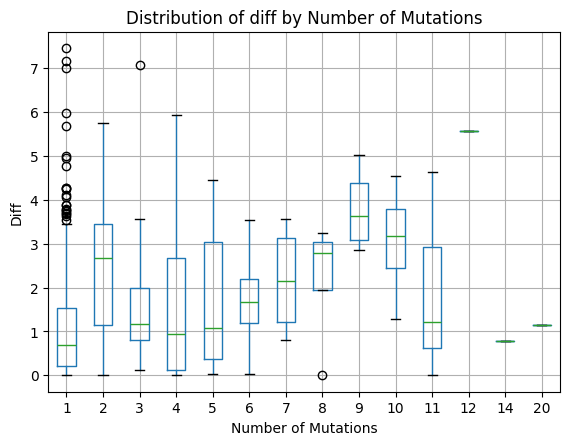

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
final_result_merged.boxplot(column='diff', by='num_muts')
plt.title('Distribution of diff by Number of Mutations')
plt.suptitle('')
plt.xlabel('Number of Mutations')
plt.ylabel('Diff')
plt.show()


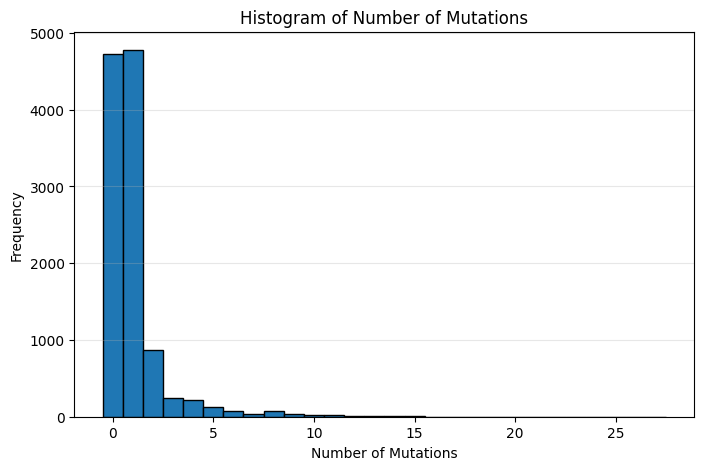

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# assuming your DataFrame is named df
# create the new column
affinity_df['number_of_mutations'] = (
    affinity_df['mutstr']
    .fillna('')                          # replace NaN with empty string
    .apply(lambda x: 0 if x == '' else len(x.split(',')))  # count mutations
)

# plot a histogram
plt.figure(figsize=(8, 5))
plt.hist(affinity_df['number_of_mutations'], bins=range(affinity_df['number_of_mutations'].max() + 2), align='left', edgecolor='black')
plt.xlabel('Number of Mutations')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Mutations')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [11]:
# Total number of mutations across all rows
total_mutations = affinity_df['number_of_mutations'].sum()
print("Total number of mutations:", total_mutations)

Total number of mutations: 11281


In [12]:
549 / 11281

0.04866589841326124